# Compensation Trends and Job Posting Behavior Analysis

## Overview
This project analyzes one month of scraped compensation and job posting data to identify patterns in:
- job posting volume
- compensation trends
- day-of-week posting behavior

The analysis focuses on whether higher job volume aligns with higher compensation and whether posting behavior differs over time.

## Tools Used
- Python
- pandas
- matplotlib

## Key Questions
1. Which days have the highest job posting volume?
2. Which days have the highest average compensation?
3. Do high-volume posting days also represent the highest-paying opportunities?

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## Load and Prepare the Data

The dataset includes:
- posting date
- minimum compensation
- maximum compensation
- job metadata

To prepare the data for analysis:
- column names are cleaned
- date fields are converted
- compensation values are converted to numeric format
- midpoint compensation is calculated as the average of minimum and maximum compensation

In [2]:
df = pd.read_excel("gaswork_anes april national.xlsx")

df = df.rename(columns={
    "Ref #": "Ref",
    "Date Posted": "Date_Posted",
    "Job Link": "Job_Link",
    "Min $": "Min",
    "Max $": "Max"
})

df["Date_Posted"] = pd.to_datetime(df["Date_Posted"], errors="coerce")
df["Min"] = pd.to_numeric(df["Min"], errors="coerce")
df["Max"] = pd.to_numeric(df["Max"], errors="coerce")

df["mid_compensation"] = (df["Min"] + df["Max"]) / 2.0

df.head()

,Compare,Ref,City,State,Brief Description,Duration,part time or not,Min,Max,User Type,Company,Updated,Date_Posted,Job_Link,mid_compensation
0,NaN,324400,324400,Mobile,Alabama,General and/or Subspecialist Anesthesiologist....,Full Time,525000.0,700000.0,W-2,Facility: Hospital,USA Health,2026-04-15,https://www.gaswork.com/post/324400,612500.0
1,NaN,324401,324401,Mobile,Alabama,"Pediatric Anesthesiologist, $75,000 Sign-On Bo...",Full Time,525000.0,700000.0,W-2,Facility: Hospital,USA Health,2026-04-15,https://www.gaswork.com/post/324401,612500.0
2,NaN,572019,572019,Huntsville,Alabama,Anesthesiologist needed at well-established ou...,Full Time,NaN,NaN,W-2,Group: Private Practice,The Surgery Center of Huntsville,2026-04-14,https://www.gaswork.com/post/572019,NaN
3,NaN,567174,567174,Saraland,Alabama,Work only 26 weeks per year in a 4 day work we...,Full Time,250000.0,250000.0,W-2,Management Firm,LifeLinc Anesthesia,2026-04-14,https://www.gaswork.com/post/567174,250000.0
4,NaN,356646,356646,Mobile,Alabama,Come join our team at USA Health Providence on...,Full Time,500000.0,500000.0,W-2,Facility: Hospital,USA Health- Providence Hospital,2026-04-16,https://www.gaswork.com/post/356646,500000.0


## Create Day-of-Week Variable

To analyze posting behavior by day, the posting date is converted into a day-of-week category.  
This allows for comparison of both posting volume and average compensation across the week.

In [4]:
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

df["day_of_week"] = pd.Categorical(
    df["Date_Posted"].dt.day_name(),
    categories=day_order,
    ordered=True
)

df[["Date_Posted", "day_of_week"]].head()

,Date_Posted,day_of_week
0,2026-04-15,Wednesday
1,2026-04-15,Wednesday
2,2026-04-14,Tuesday
3,2026-04-14,Tuesday
4,2026-04-16,Thursday


## Posting Volume by Day of Week

This section evaluates which days had the highest number of job postings.

This helps identify whether employers tend to post jobs on certain days more frequently than others.

In [5]:
posting_by_day = (
    df.groupby("day_of_week", observed=False)
      .size()
      .reset_index(name="posting_count")
      .dropna(subset=["day_of_week"])
)

posting_by_day

,day_of_week,posting_count
0,Monday,220
1,Tuesday,254
2,Wednesday,196
3,Thursday,837
4,Friday,62
5,Saturday,11
6,Sunday,22


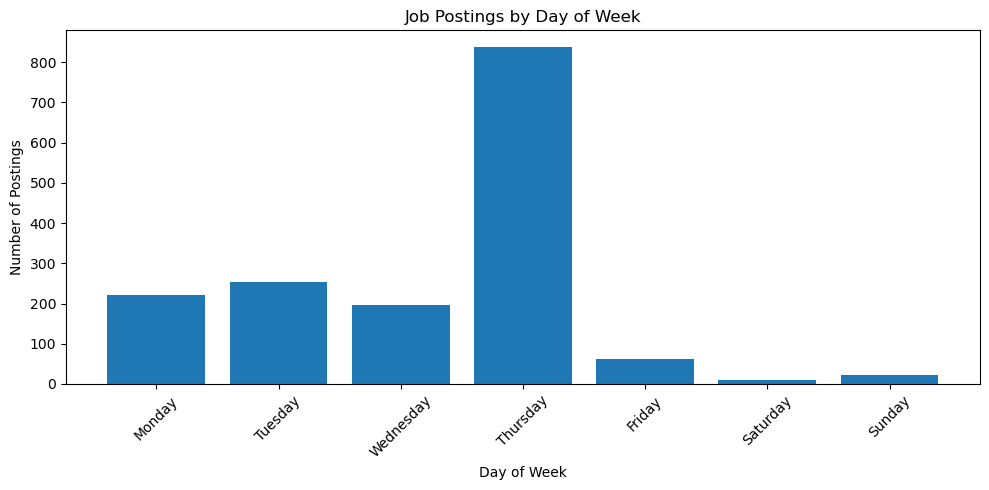

In [6]:
plt.figure(figsize=(10, 5))
plt.bar(posting_by_day["day_of_week"].astype(str), posting_by_day["posting_count"])
plt.title("Job Postings by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Number of Postings")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Insight

Posting activity is concentrated during the workweek, with Thursday showing the highest number of job postings by a wide margin.

This suggests that employers are more likely to release opportunities mid-to-late week, while weekend posting activity is minimal.

## Average Compensation by Day of Week

To evaluate compensation trends, midpoint compensation is calculated using the average of the posted minimum and maximum values.

This helps determine whether the days with the highest posting volume also correspond to the highest-paying opportunities.

In [7]:
comp_by_day = (
    df.dropna(subset=["mid_compensation", "day_of_week"])
      .groupby("day_of_week", observed=False)["mid_compensation"]
      .mean()
      .reset_index()
)

comp_by_day

,day_of_week,mid_compensation
0,Monday,544825.581395
1,Tuesday,523737.623762
2,Wednesday,594491.525424
3,Thursday,559135.338346
4,Friday,510119.047619
5,Saturday,516666.666667
6,Sunday,491250.000000


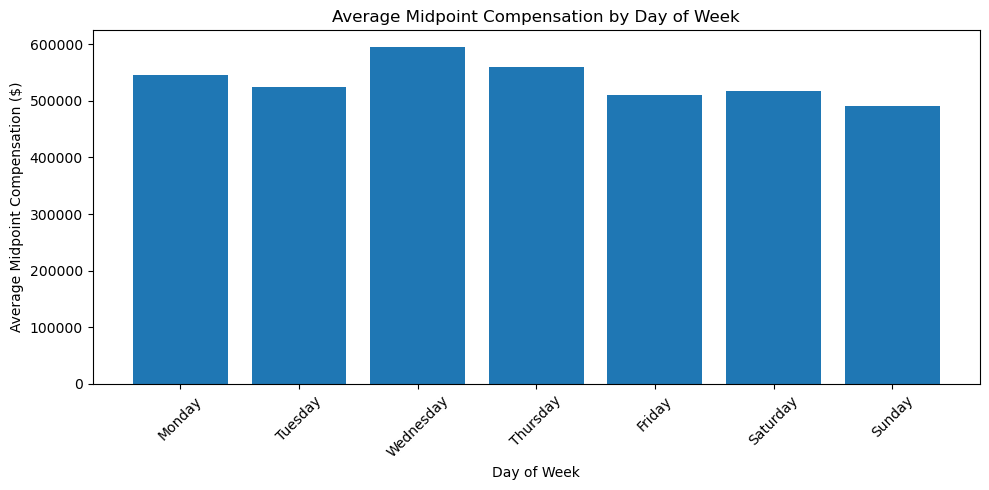

In [8]:
plt.figure(figsize=(10, 5))
plt.bar(comp_by_day["day_of_week"].astype(str), comp_by_day["mid_compensation"])
plt.title("Average Midpoint Compensation by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Midpoint Compensation ($)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Insight

Although Thursday has the highest posting volume, Wednesday has the highest average midpoint compensation.

This suggests that high-volume posting days do not necessarily align with the highest-paying opportunities. Higher-paying roles may be posted more selectively earlier in the week.

## Compare Posting Volume and Compensation

To directly compare posting behavior and pay trends, posting counts and average compensation are summarized together in one table.

In [9]:
summary = (
    df.dropna(subset=["mid_compensation", "day_of_week"])
      .groupby("day_of_week", observed=False)
      .agg(
          posting_count=("day_of_week", "count"),
          avg_compensation=("mid_compensation", "mean")
      )
      .reset_index()
)

summary

,day_of_week,posting_count,avg_compensation
0,Monday,86,544825.581395
1,Tuesday,101,523737.623762
2,Wednesday,59,594491.525424
3,Thursday,266,559135.338346
4,Friday,21,510119.047619
5,Saturday,3,516666.666667
6,Sunday,10,491250.000000


## Key Takeaway

The analysis shows a clear difference between job posting volume and compensation value:

- **Thursday** is the dominant day for posting volume
- **Wednesday** has the highest average compensation

This indicates that employers may use different timing strategies for standard openings versus higher-value opportunities.

## Conclusion

This analysis identified two important patterns in the dataset:

1. Job posting behavior is concentrated during the workweek, especially on Thursdays.
2. Higher compensation opportunities tend to appear on Wednesdays, despite lower posting volume.

Together, these findings suggest that high posting activity does not necessarily indicate premium opportunities. This creates a useful distinction between volume-based and value-based job market behavior.

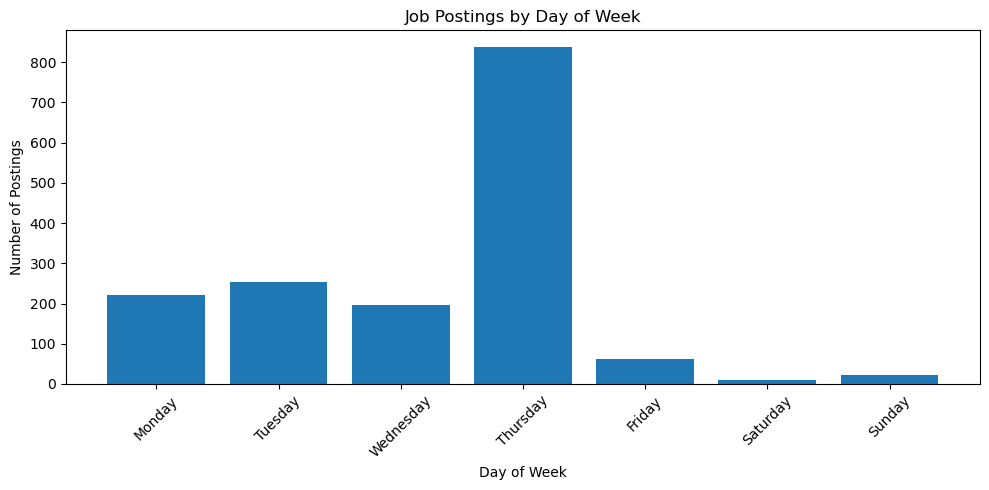

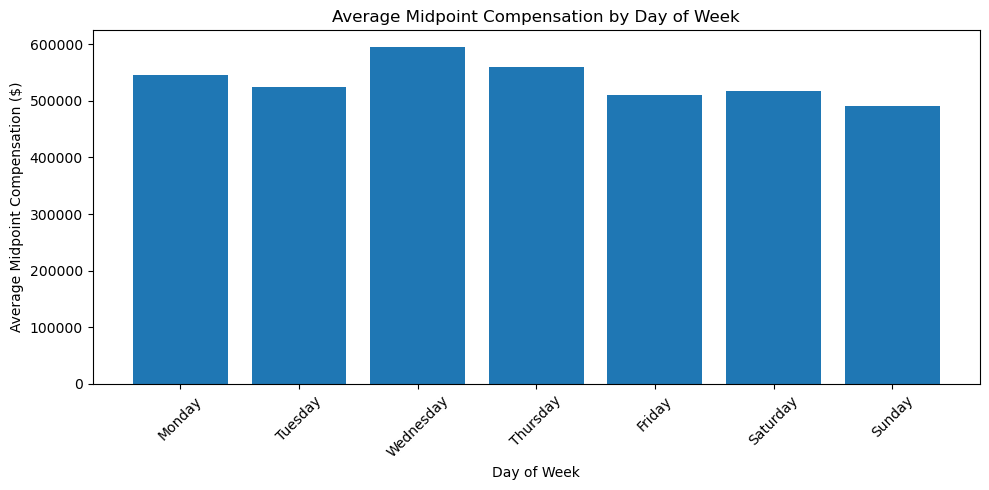

In [10]:
plt.figure(figsize=(10, 5))
plt.bar(posting_by_day["day_of_week"].astype(str), posting_by_day["posting_count"])
plt.title("Job Postings by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Number of Postings")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("job_postings_by_day.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(comp_by_day["day_of_week"].astype(str), comp_by_day["mid_compensation"])
plt.title("Average Midpoint Compensation by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Midpoint Compensation ($)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("avg_compensation_by_day.png", dpi=300, bbox_inches="tight")
plt.show()

In [11]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Auto-detect Desktop path
desktop_path = os.path.join(os.path.expanduser("~"), "Desktop")

# File paths
file1 = os.path.join(desktop_path, "job_postings_by_day.png")
file2 = os.path.join(desktop_path, "avg_compensation_by_day.png")

# -----------------------------
# Chart 1: Job Postings
# -----------------------------
plt.figure(figsize=(10, 5))

plt.bar(
    posting_by_day["day_of_week"].astype(str),
    posting_by_day["posting_count"]
)

plt.title("Job Posting Volume by Day of Week", fontsize=14, fontweight="bold")
plt.xlabel("Day of Week")
plt.ylabel("Number of Postings")
plt.xticks(rotation=45)

# Value labels
for i, v in enumerate(posting_by_day["posting_count"]):
    plt.text(i, v + 5, str(v), ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(file1, dpi=300, bbox_inches="tight")
plt.close()

# -----------------------------
# Chart 2: Compensation
# -----------------------------
plt.figure(figsize=(10, 5))

plt.bar(
    comp_by_day["day_of_week"].astype(str),
    comp_by_day["mid_compensation"]
)

plt.title("Average Compensation by Day of Week", fontsize=14, fontweight="bold")
plt.xlabel("Day of Week")
plt.ylabel("Average Compensation ($)")
plt.xticks(rotation=45)

# Format y-axis as dollars
plt.gca().yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"${int(x):,}")
)

# Value labels
for i, v in enumerate(comp_by_day["mid_compensation"]):
    plt.text(i, v + 5000, f"${int(v):,}", ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(file2, dpi=300, bbox_inches="tight")
plt.close()

print("Saved to Desktop:")
print(file1)
print(file2)

Saved to Desktop:
C:\Users\cnico\Desktop\job_postings_by_day.png
C:\Users\cnico\Desktop\avg_compensation_by_day.png
